In [5]:
"""
Pipeline de inferência com PIRNNs (Physics-Informed RNNs) para estimar a
trajetória (x, y, theta) de um robô de tração diferencial.

Treinamento:
    Dados
      -> normalização com StandardScaler
      -> CreateSequences()
      -> PIRNN
      -> saída normalizada
      -> inverse_transform()
      -> integração
"""

# ==========================================================================
# IMPORTS
# ==========================================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from scipy.interpolate import interp1d
import joblib
import matplotlib.pyplot as plt


# ==========================================================================
# CONFIGURAÇÃO
# ==========================================================================

MODEL_DIR = "models"

MODEL_X = "model_arch16-5_r0.01_Ld0.7_Lp0.3_seed9441.keras"
MODEL_Y = "model_arch15-10_r0.01_Ld0.7_Lp0.3_seed7538.keras"
MODEL_T = "model_arch22-14-10_r0.01_Ld0.7_Lp0.3_seed9359.keras"

# Ordem EXATA usada no treinamento
PREDICTORS_T = ["PwmD", "PwmE", "sPwm", "dPwm"]

PREDICTORS_X = ["PwmD", "PwmE", "sPwm", "dPwm", "cosTheta"]

PREDICTORS_Y = ["PwmD", "PwmE", "sPwm", "dPwm", "sinTheta"]

INPUT_SIZE_T = len(PREDICTORS_T)
INPUT_SIZE_X = len(PREDICTORS_X)
INPUT_SIZE_Y = len(PREDICTORS_Y)

OUTPUT_SIZE = 1

# Deve ser o mesmo TIME_STEPS usado no treinamento
T_LAG = 15

# Mesmo período de amostragem usado no treinamento
T_SAMPLE = 0.07


# ==========================================================================
# CURVAS PWM x VELOCIDADE
# ==========================================================================

PWM_CURVE_D = "PWMxVelocidade/ensaio_malha_aberta_D.csv"
PWM_CURVE_E = "PWMxVelocidade/ensaio_malha_aberta_E.csv"


# ==========================================================================
# SCALERS
# ==========================================================================

SCALER_PATHS = {
    "theta": (
        "./scalers-theta/scaler.pkl",
        "./scalers-theta/out_scaler.pkl"
    ),

    "x": (
        "./scalers-x/scaler.pkl",
        "./scalers-x/out_scaler.pkl"
    ),

    "y": (
        "./scalers-y/scaler.pkl",
        "./scalers-y/out_scaler.pkl"
    ),
}


# ==========================================================================
# CACHE
# ==========================================================================

_MODEL_CACHE = {}
_SCALER_CACHE = {}
_PWM_INTERP_CACHE = {}


# ==========================================================================
# CARREGAMENTO DOS MODELOS
# ==========================================================================

def LoadModelFrom(model_filename):
    """
    Carrega um modelo .keras.

    O modelo é armazenado em cache para evitar carregamentos repetidos.
    """

    if model_filename in _MODEL_CACHE:
        return _MODEL_CACHE[model_filename]

    model_path = os.path.join(MODEL_DIR, model_filename)

    if not os.path.exists(model_path):
        raise FileNotFoundError(
            f"Modelo não encontrado em: {model_path}"
        )

    model = tf.keras.saving.load_model(model_path)

    _MODEL_CACHE[model_filename] = model

    return model


# ==========================================================================
# CARREGAMENTO DOS SCALERS
# ==========================================================================

def _get_scaler(name):
    """
    Carrega os scalers de entrada e saída correspondentes à rede.

    Retorna:
        scaler_in
        scaler_out
    """

    if name in _SCALER_CACHE:
        return _SCALER_CACHE[name]

    in_path, out_path = SCALER_PATHS[name]

    if not os.path.exists(in_path):
        raise FileNotFoundError(
            f"Scaler de entrada não encontrado: {in_path}"
        )

    if not os.path.exists(out_path):
        raise FileNotFoundError(
            f"Scaler de saída não encontrado: {out_path}"
        )

    scaler_in = joblib.load(in_path)
    scaler_out = joblib.load(out_path)

    _SCALER_CACHE[name] = (scaler_in, scaler_out)

    return scaler_in, scaler_out


# ==========================================================================
# CREATE SEQUENCES
# ==========================================================================

def CreateSequences(input_data, target_data, timesteps):
    """
    MESMA função utilizada no treinamento.

    Cria sequências causais sem padding.

    Para:

        timesteps = 3

    temos:

        X[0:3] -> Y[3]
        X[1:4] -> Y[4]
        X[2:5] -> Y[5]

    Retorna:

        X_seq:
            (N - timesteps, timesteps, n_features)

        Y_seq:
            (N - timesteps, n_outputs)
    """

    X_seq = []
    Y_seq = []

    for i in range(timesteps, len(input_data)):

        X_seq.append(
            input_data.iloc[i - timesteps:i].values
        )

        Y_seq.append(
            target_data.iloc[i]
        )

    return np.array(X_seq), np.array(Y_seq)


# ==========================================================================
# BUILD WINDOWS
# ==========================================================================

def _build_windows(features_df, columns, scaler, t_lag):
    """
    Faz:

        1. seleção das features;
        2. normalização usando o scaler do treinamento;
        3. criação das janelas exatamente como CreateSequences().

    NÃO utiliza padding.

    Entrada:
        N amostras

    Saída:
        N - t_lag janelas
    """

    # --------------------------------------------------------------
    # Seleciona as mesmas colunas usadas durante o treinamento
    # --------------------------------------------------------------

    X = features_df[columns].to_numpy(dtype=float)
    X_scaled = scaler.transform(X)
    X_windows = np.array([
        X_scaled[i - t_lag:i]
        for i in range(t_lag, len(X_scaled))
    ])

    return X_windows


# ==========================================================================
# CONVERSÃO VELOCIDADE -> PWM
# ==========================================================================

def _build_speed_to_pwm_interpolator(csv_path):
    """
    Constrói um interpolador:

        Velocidade_rad_s -> PWM
    """

    if csv_path in _PWM_INTERP_CACHE:
        return _PWM_INTERP_CACHE[csv_path]

    if not os.path.exists(csv_path):
        raise FileNotFoundError(
            f"Curva PWM x Velocidade não encontrada em: {csv_path}"
        )

    df = pd.read_csv(csv_path)

    # Média para velocidades repetidas
    df = df.groupby(
        "Velocidade_rad_s",
        as_index=False
    )["PWM"].mean()

    # Ordena pela velocidade
    df = df.sort_values("Velocidade_rad_s")

    interpolador = interp1d(
        df["Velocidade_rad_s"].to_numpy(),
        df["PWM"].to_numpy(),
        kind="linear",
        bounds_error=False,
        fill_value="extrapolate"
    )

    _PWM_INTERP_CACHE[csv_path] = interpolador

    return interpolador


# ==========================================================================
# CONVERTER VELOCIDADE PARA PWM
# ==========================================================================

def ConvertSpeedToPWM(S_d, S_e):
    """
    Converte as velocidades de referência das rodas para PWM.
    """

    f_conv_d = _build_speed_to_pwm_interpolator(
        PWM_CURVE_D
    )

    f_conv_e = _build_speed_to_pwm_interpolator(
        PWM_CURVE_E
    )

    S_d = np.atleast_1d(
        np.asarray(S_d, dtype=float)
    )

    S_e = np.atleast_1d(
        np.asarray(S_e, dtype=float)
    )

    PwmD = f_conv_d(S_d)
    PwmE = f_conv_e(S_e)

    return PwmD, PwmE


# ==========================================================================
# GERAR ENTRADA DAS PIRNNs
# ==========================================================================

def GeneratePIRNNInput(S_d, S_e):
    """
    Gera:

        PwmD
        PwmE
        sPwm
        dPwm
    """

    PwmD, PwmE = ConvertSpeedToPWM(S_d, S_e)

    df = pd.DataFrame({
        "PwmD": PwmD,
        "PwmE": PwmE
    })

    df["sPwm"] = (
        df["PwmD"] +
        df["PwmE"]
    )

    df["dPwm"] = (
        df["PwmD"] -
        df["PwmE"]
    )

    return df


# ==========================================================================
# INTEGRAÇÃO NUMÉRICA
# ==========================================================================

def NumericalIntegration(q0, dq, dt=T_SAMPLE):
    """
    Integração por Euler para frente.

    IMPORTANTE:
    O vetor dq recebido já corresponde aos instantes:

        T_LAG, T_LAG+1, ..., N-1
    """

    dq = np.asarray(
        dq,
        dtype=float
    ).flatten()

    return q0 + np.cumsum(
        dq * dt
    )


# ==========================================================================
# PREDIÇÃO COMPLETA
# ==========================================================================

def CompleteModelPredict(
    S_d,
    S_e,
    x0=0.0,
    y0=0.7,
    theta0=0.0
):
    """

    """

    # ==================================================================
    # Verificação dos dados
    # ==================================================================

    S_d = np.asarray(
        S_d,
        dtype=float
    ).flatten()

    S_e = np.asarray(
        S_e,
        dtype=float
    ).flatten()

    if len(S_d) != len(S_e):
        raise ValueError(
            "S_d e S_e precisam possuir o mesmo comprimento."
        )

    N = len(S_d)

    if N <= T_LAG:
        raise ValueError(
            f"A quantidade de amostras ({N}) precisa ser maior "
            f"que T_LAG ({T_LAG})."
        )

    # ==================================================================
    # Carrega os modelos
    # ==================================================================

    x_model = LoadModelFrom(
        MODEL_X
    )

    y_model = LoadModelFrom(
        MODEL_Y
    )

    t_model = LoadModelFrom(
        MODEL_T
    )

    # ==================================================================
    # Carrega os scalers
    # ==================================================================

    scaler_in_t, scaler_out_t = _get_scaler("theta")
    scaler_in_x, scaler_out_x = _get_scaler("x")
    scaler_in_y, scaler_out_y = _get_scaler("y")

    # ==================================================================
    # 1) Gera as features básicas
    # ==================================================================
    
    Dataset = pd.read_excel(
        "./Dados/Datasets.xlsx",
        sheet_name="Train_1"
    )

    base_input = pd.DataFrame({
        "PwmD": Dataset["PwmD"],
        "PwmE": Dataset["PwmE"],
        "sPwm": Dataset["PwmD"] + Dataset["PwmE"],
        "dPwm": Dataset["PwmD"] - Dataset["PwmE"]
    })
    
    
    base_input = GeneratePIRNNInput(S_d, S_e)


    # ==================================================================
    # 2) PIRNN THETA
    # ==================================================================

    windows_t = _build_windows(
        base_input,
        PREDICTORS_T,
        scaler_in_t,
        T_LAG
    )

    # --------------------------------------------------------------
    # Verificação
    # --------------------------------------------------------------

    expected_windows = N - T_LAG

    if len(windows_t) != expected_windows:
        raise RuntimeError(
            f"Número incorreto de janelas para theta: "
            f"{len(windows_t)} != {expected_windows}"
        )

    # --------------------------------------------------------------
    # Predição normalizada
    # --------------------------------------------------------------

    dtheta_scaled = t_model.predict(
        windows_t,
        verbose=0
    )

    # --------------------------------------------------------------
    # Retorna para unidade original
    # --------------------------------------------------------------

    dtheta = scaler_out_t.inverse_transform(
        dtheta_scaled
    ).flatten()

    # --------------------------------------------------------------
    # Integração
    #
    # A primeira previsão corresponde ao instante T_LAG.
    # --------------------------------------------------------------

    theta_pred = NumericalIntegration(
        theta0,
        dtheta
    )

    # --------------------------------------------------------------
    # Vetor completo
    #
    # Os primeiros T_LAG pontos não foram previstos.
    # Para manter alinhamento temporal, usamos theta0 nesses pontos.
    # --------------------------------------------------------------

    theta_hat = np.concatenate([
        np.full(T_LAG, theta0),
        theta_pred
    ])

    # Agora:
    #
    # len(theta_hat) == N
    #

    # ==================================================================
    # 3) FEATURES PARA X
    # ==================================================================

    x_input = base_input.copy()

    x_input["cosTheta"] = np.cos(
        theta_hat
    )

    # ==================================================================
    # 4) PIRNN X
    # ==================================================================

    windows_x = _build_windows(
        x_input,
        PREDICTORS_X,
        scaler_in_x,
        T_LAG
    )

    dx_scaled = x_model.predict(
        windows_x,
        verbose=0
    )

    dx = scaler_out_x.inverse_transform(
        dx_scaled
    ).flatten()

    # --------------------------------------------------------------
    # Integração
    # --------------------------------------------------------------

    x_pred = NumericalIntegration(
        x0,
        dx
    )

    # --------------------------------------------------------------
    # Vetor completo
    #
    # Os primeiros T_LAG instantes mantêm x0.
    # --------------------------------------------------------------

    x_hat = np.concatenate([
        np.full(T_LAG, x0),
        x_pred
    ])

    # ==================================================================
    # 5) FEATURES PARA Y
    # ==================================================================

    y_input = base_input.copy()

    y_input["sinTheta"] = np.sin(
        theta_hat
    )

    # ==================================================================
    # 6) PIRNN Y
    # ==================================================================

    windows_y = _build_windows(
        y_input,
        PREDICTORS_Y,
        scaler_in_y,
        T_LAG
    )

    dy_scaled = y_model.predict(
        windows_y,
        verbose=0
    )

    dy = scaler_out_y.inverse_transform(
        dy_scaled
    ).flatten()

    # --------------------------------------------------------------
    # Integração
    # --------------------------------------------------------------

    y_pred = NumericalIntegration(
        y0,
        dy
    )

    # --------------------------------------------------------------
    # Vetor completo
    # --------------------------------------------------------------

    y_hat = np.concatenate([
        np.full(T_LAG, y0),
        y_pred
    ])

    # ==================================================================
    # Verificações finais
    # ==================================================================

    assert len(base_input) == N
    assert len(theta_hat) == N
    assert len(x_hat) == N
    assert len(y_hat) == N

    # ==================================================================
    # Retorno
    # ==================================================================

    return base_input, theta_hat, x_hat, y_hat, dtheta, dx, dy    

In [2]:
def PlotPWM(base_input, PwmD_real, PwmE_real, dt=T_SAMPLE):
    import matplotlib.pyplot as plt
    import numpy as np

    # Vetor de tempo
    t = np.arange(len(base_input)) * dt

    # Converte para arrays
    PwmD_real = np.asarray(PwmD_real).flatten()
    PwmE_real = np.asarray(PwmE_real).flatten()

    PwmD_est = np.asarray(base_input["PwmD"]).flatten()
    PwmE_est = np.asarray(base_input["PwmE"]).flatten()

    # Garante mesmo tamanho
    n = min(
        len(t),
        len(PwmD_real),
        len(PwmE_real),
        len(PwmD_est),
        len(PwmE_est)
    )

    t = t[:n]
    PwmD_real = PwmD_real[:n]
    PwmE_real = PwmE_real[:n]
    PwmD_est = PwmD_est[:n]
    PwmE_est = PwmE_est[:n]

    # Gráficos
    fig, axs = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    # Roda direita
    axs[0].plot(t, PwmD_real, label="Real")
    axs[0].plot(t, PwmD_est, "--", label="Estimado")

    axs[0].set_ylabel("PWM")
    axs[0].set_title("PWM - Roda Direita (PwmD)")
    axs[0].legend()
    axs[0].grid(True, linestyle="--", alpha=0.5)

    # Roda esquerda
    axs[1].plot(t, PwmE_real, label="Real")
    axs[1].plot(t, PwmE_est, "--", label="Estimado")

    axs[1].set_xlabel("Tempo [s]")
    axs[1].set_ylabel("PWM")
    axs[1].set_title("PWM - Roda Esquerda (PwmE)")
    axs[1].legend()
    axs[1].grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

In [3]:
"""
Alterações no pipeline PIRNN para plotar 7 figuras:

    dx, dy, dtheta    -> saídas "cruas" das redes (antes da integração)
    x, y, theta        -> trajetória integrada
    y em função de x    -> trajetória completa

Layout: grade 3x2 (6 gráficos temporais) + 1 subplot extra
        ocupando a linha inferior inteira (trajetória completa).

MUDANÇA NECESSÁRIA em CompleteModelPredict: as saídas cruas das redes
(variáveis `dtheta`, `dx`, `dy`) já são calculadas ali, só não são
retornadas. Troque o `return` final por:

    return base_input, theta_hat, x_hat, y_hat, dtheta, dx, dy
"""

import numpy as np
import matplotlib.pyplot as plt

T_SAMPLE = 0.07  # mesmo valor usado no pipeline


def PlotTrajectory(
    x_hat, y_hat, theta_hat,
    x_real, y_real, theta_real,
    dx_hat, dy_hat, dtheta_hat,
    dx_real, dy_real, dtheta_real,
    dt=T_SAMPLE,
):
    """
    Plota 7 figuras comparando Real x Estimado (rede):

        1. dx      (derivada de x)
        2. dy      (derivada de y)
        3. dtheta  (derivada de theta)
        4. x
        5. y
        6. theta
        7. trajetória completa: y em função de x

    Layout: grade 3x2 para as 6 primeiras + 1 subplot extra (linha
    inferior, ocupando as duas colunas) para a trajetória completa.

    Todos os parâmetros são arrays já prontos (reais e estimados).
    Cada par (ex.: dx_hat/dx_real) precisa ter o mesmo tamanho entre si.
    """

    x_hat = np.asarray(x_hat, dtype=float).flatten()
    y_hat = np.asarray(y_hat, dtype=float).flatten()
    theta_hat = np.asarray(theta_hat, dtype=float).flatten()
    x_real = np.asarray(x_real, dtype=float).flatten()
    y_real = np.asarray(y_real, dtype=float).flatten()
    theta_real = np.asarray(theta_real, dtype=float).flatten()

    dx_hat = np.asarray(dx_hat, dtype=float).flatten()
    dy_hat = np.asarray(dy_hat, dtype=float).flatten()
    dtheta_hat = np.asarray(dtheta_hat, dtype=float).flatten()
    dx_real = np.asarray(dx_real, dtype=float).flatten()
    dy_real = np.asarray(dy_real, dtype=float).flatten()
    dtheta_real = np.asarray(dtheta_real, dtype=float).flatten()

    # ----------------------------------------------------------------
    # dx_hat/dy_hat/dtheta_hat são saídas cruas da rede: começam no
    # instante T_LAG (tamanho N - T_LAG). Se o "_real" correspondente
    # vier com tamanho N (série completa), pegamos só a cauda final,
    # que é o trecho temporalmente alinhado com o "_hat".
    # ----------------------------------------------------------------

    def _align_tail(real, hat):
        if len(real) != len(hat):
            real = real[-len(hat):]
        return real

    dx_real = _align_tail(dx_real, dx_hat)
    dy_real = _align_tail(dy_real, dy_hat)
    dtheta_real = _align_tail(dtheta_real, dtheta_hat)

    t_pos = np.arange(len(x_hat)) * dt
    t_d = np.arange(len(dx_hat)) * dt

    # --------------------------------------------------------------
    # Layout: 4 linhas x 2 colunas
    #   - 3 primeiras linhas -> grade 3x2 (dx, dy, dtheta, x, y, theta)
    #   - última linha       -> 1 subplot ocupando as 2 colunas (trajetória)
    # --------------------------------------------------------------

    fig = plt.figure(figsize=(12, 14))
    gs = fig.add_gridspec(4, 2, height_ratios=[1, 1, 1, 1.6])

    ax_dx = fig.add_subplot(gs[0, 0])
    ax_dy = fig.add_subplot(gs[0, 1])
    ax_dtheta = fig.add_subplot(gs[1, 0])
    ax_x = fig.add_subplot(gs[1, 1])
    ax_y = fig.add_subplot(gs[2, 0])
    ax_theta = fig.add_subplot(gs[2, 1])
    ax_traj = fig.add_subplot(gs[3, :])

    def _plot_pair(ax, t, real, hat, ylabel, title):
        ax.plot(t, real, label="Real")
        ax.plot(t, hat, "--", label="Estimado")
        ax.set_xlabel("Tempo [s]")
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend()
        ax.grid(True, linestyle="--", alpha=0.5)

    _plot_pair(ax_dx, t_d, dx_real, dx_hat, r"$\dot{x}$ [m/s]", r"Derivada de $x$")
    _plot_pair(ax_dy, t_d, dy_real, dy_hat, r"$\dot{y}$ [m/s]", r"Derivada de $y$")
    _plot_pair(
        ax_dtheta, t_d, dtheta_real, dtheta_hat,
        r"$\dot{\theta}$ [rad/s]", r"Derivada de $\theta$",
    )

    _plot_pair(ax_x, t_pos, x_real, x_hat, "x [m]", "Posição x")
    _plot_pair(ax_y, t_pos, y_real, y_hat, "y [m]", "Posição y")
    _plot_pair(ax_theta, t_pos, theta_real, theta_hat, r"$\theta$ [rad]", "Orientação")

    # --------------------------------------------------------------
    # Trajetória completa (y em função de x)
    # --------------------------------------------------------------

    ax_traj.plot(x_real, y_real, label="Real")
    ax_traj.plot(x_hat, y_hat, "--", label="Estimado")
    ax_traj.set_xlabel("x [m]")
    ax_traj.set_ylabel("y [m]")
    ax_traj.set_title("Trajetória completa do robô")
    ax_traj.axis("equal")
    ax_traj.legend()
    ax_traj.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

    return fig


d:\Users\sarah\Educ\Ic-2026.1\tf-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Users\sarah\Educ\Ic-2026.1\tf-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Users\sarah\Educ\Ic-2026.1\tf-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


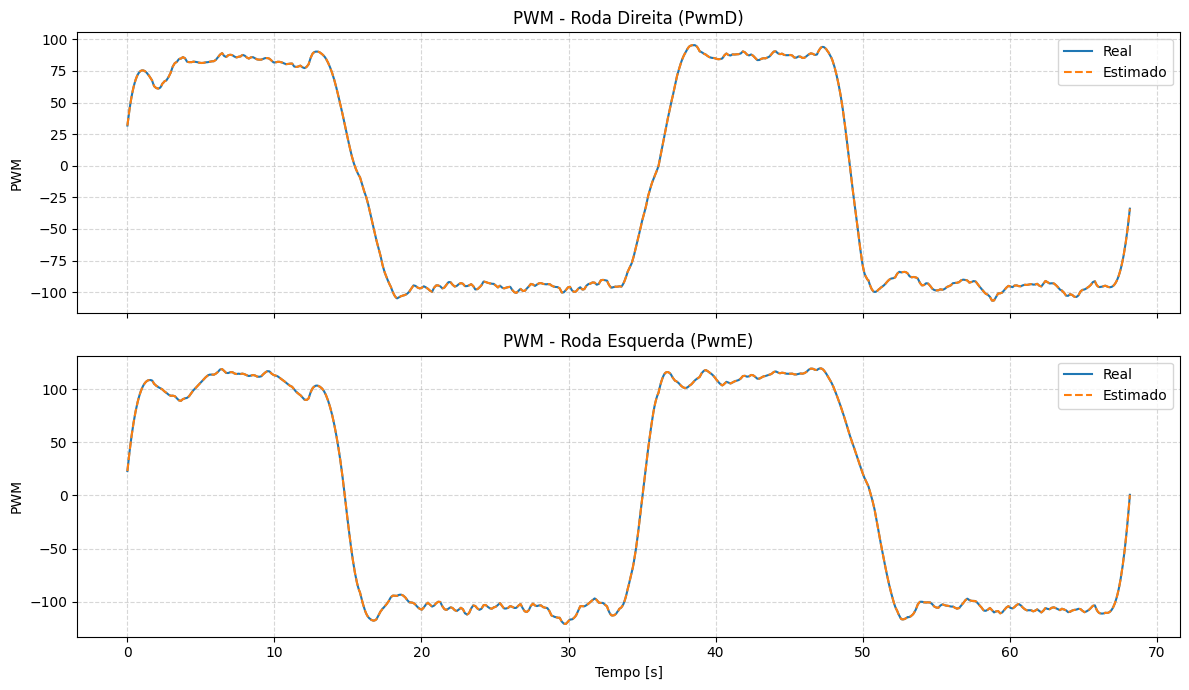

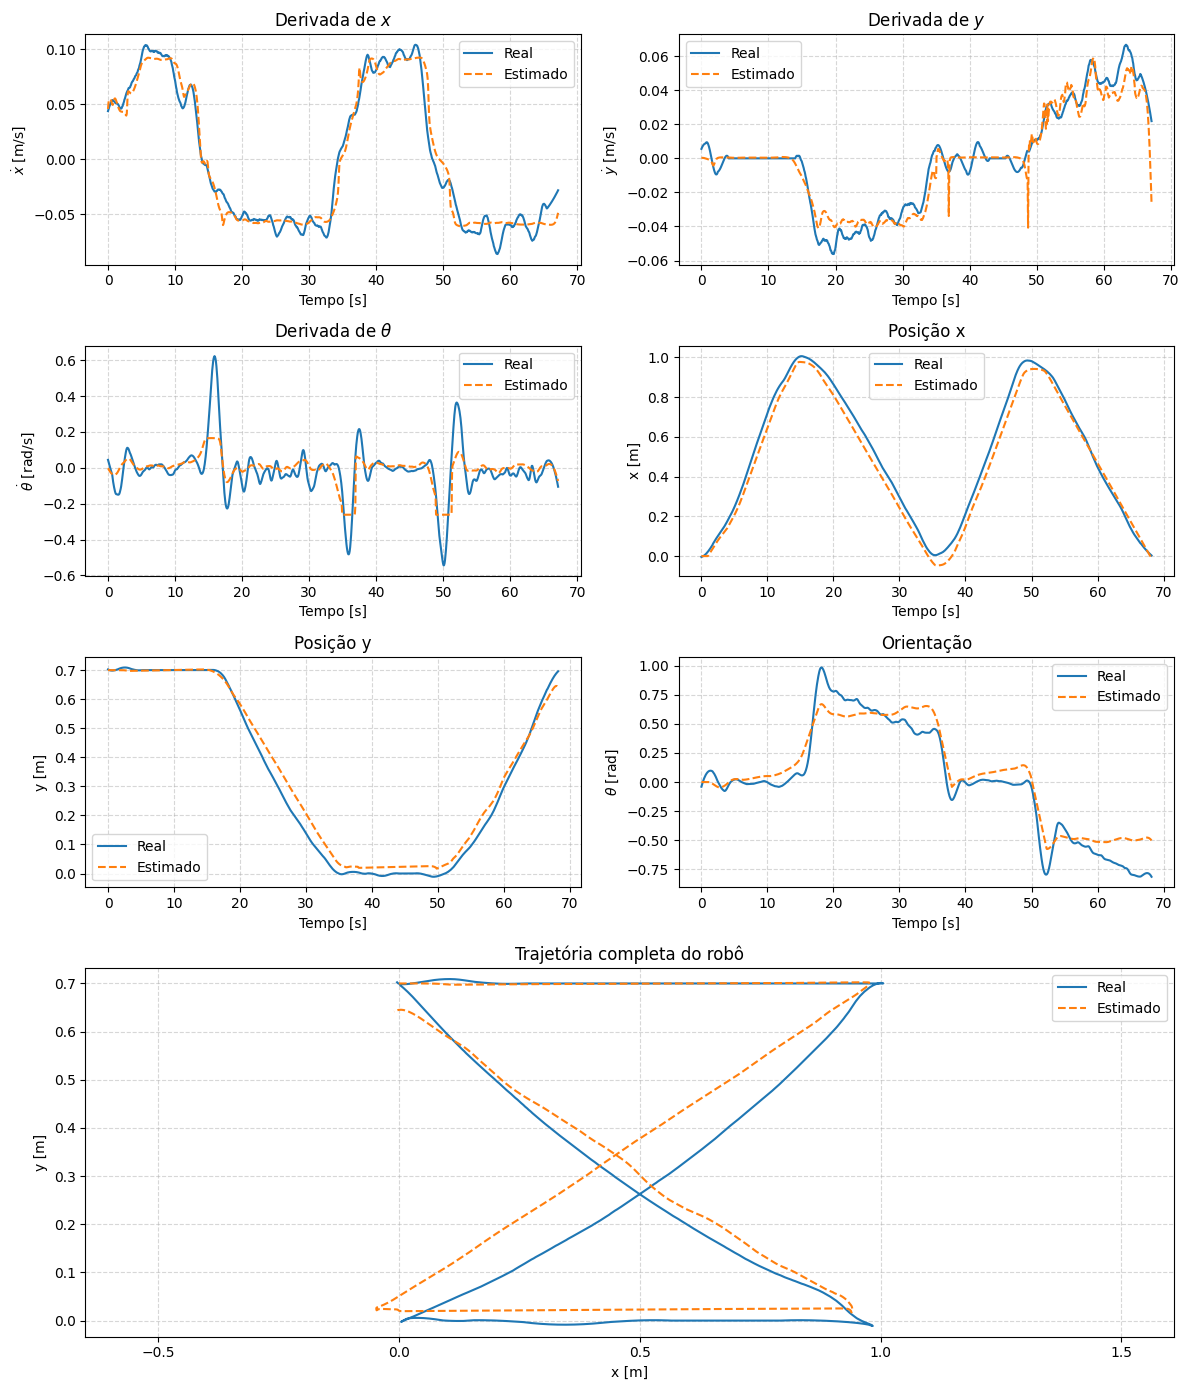

In [4]:
# --------------------------------------------------------------------------
# Exemplo de uso
# --------------------------------------------------------------------------

if __name__ == "__main__":

    Dataset = pd.read_excel("./Dados/Datasets.xlsx", sheet_name="Train_1")
    # Exemplo: velocidades de roda constantes (ajuste conforme sua trajetória real)
    S_d = Dataset["Wd"]
    S_e = Dataset["We"]
    t = np.arange(len(S_d)) * T_SAMPLE
    # Condições iniciais reais do Dataset
    x0 = Dataset["X"].iloc[0]
    y0 = Dataset["Y"].iloc[0]
    theta0 = Dataset["Theta"].iloc[0]

    # Predição
    base_input, theta_hat, x_hat, y_hat, dtheta_hat, dx_hat, dy_hat = CompleteModelPredict(S_d,
                                                                                        S_e, x0=0.0, y0=0.7, theta0=0.0)

    PlotPWM(base_input, Dataset["PwmD"], Dataset["PwmE"])

    PlotTrajectory(
        x_hat, y_hat, theta_hat,
        Dataset["X"], Dataset["Y"], Dataset["Theta"],
        dx_hat, dy_hat, dtheta_hat,
        Dataset["dX"], Dataset["dY"], Dataset["dTheta"],
     )

d:\Users\sarah\Educ\Ic-2026.1\tf-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Users\sarah\Educ\Ic-2026.1\tf-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Users\sarah\Educ\Ic-2026.1\tf-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


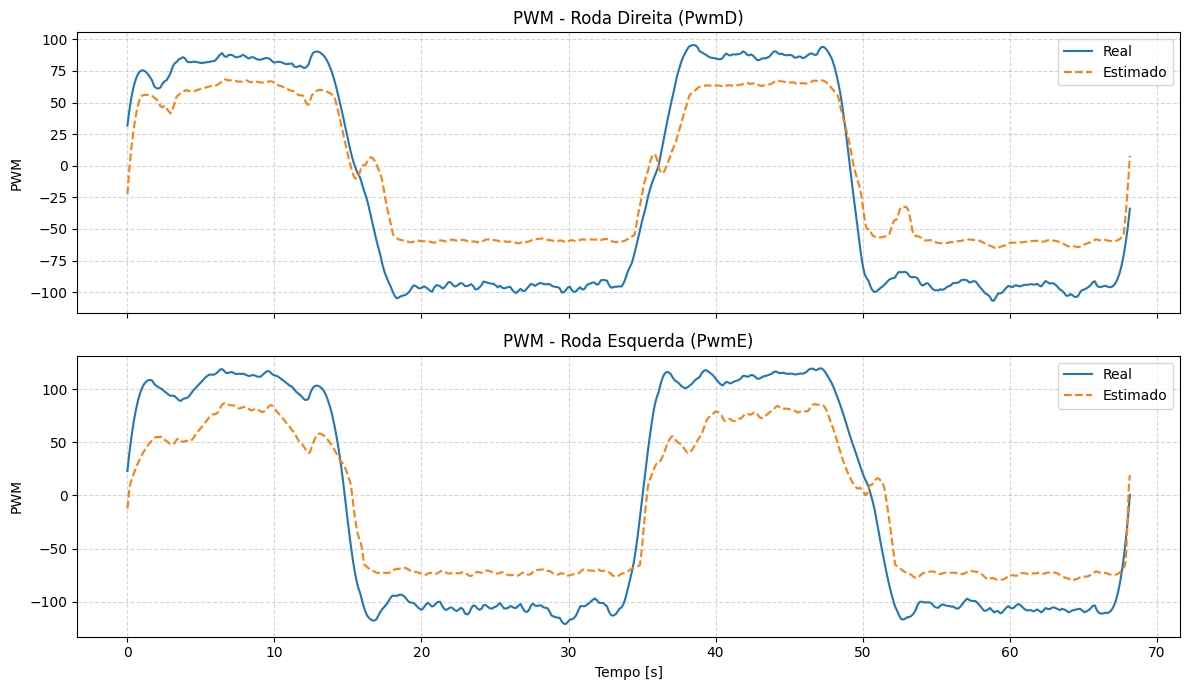

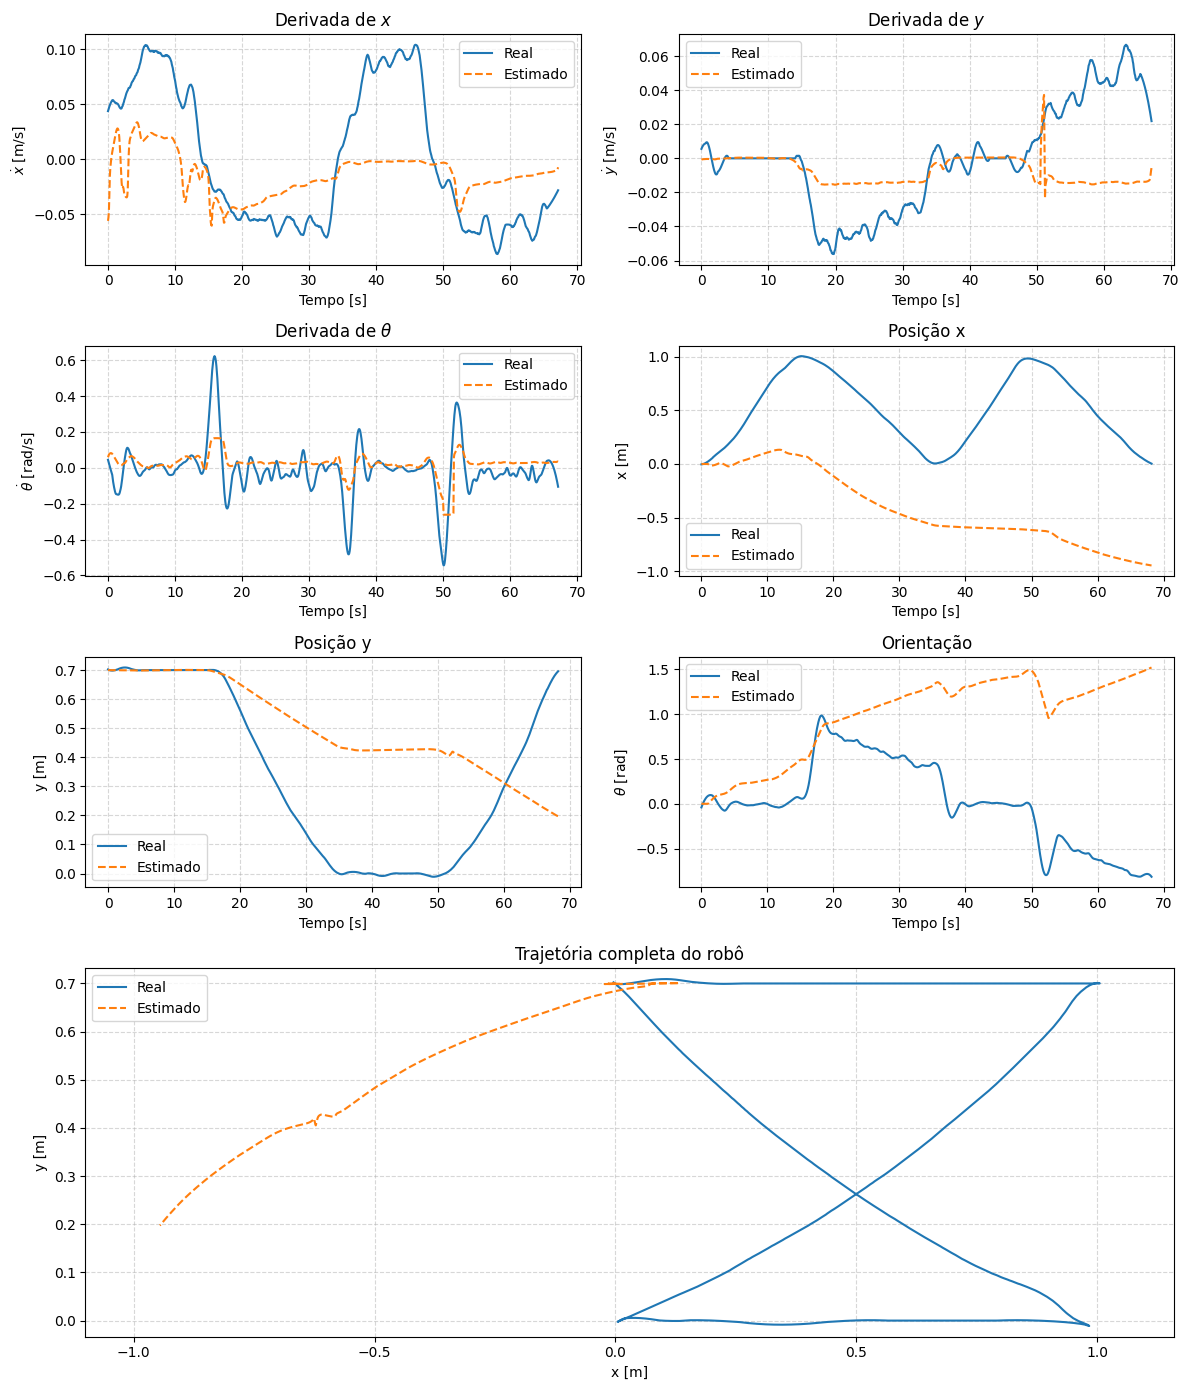

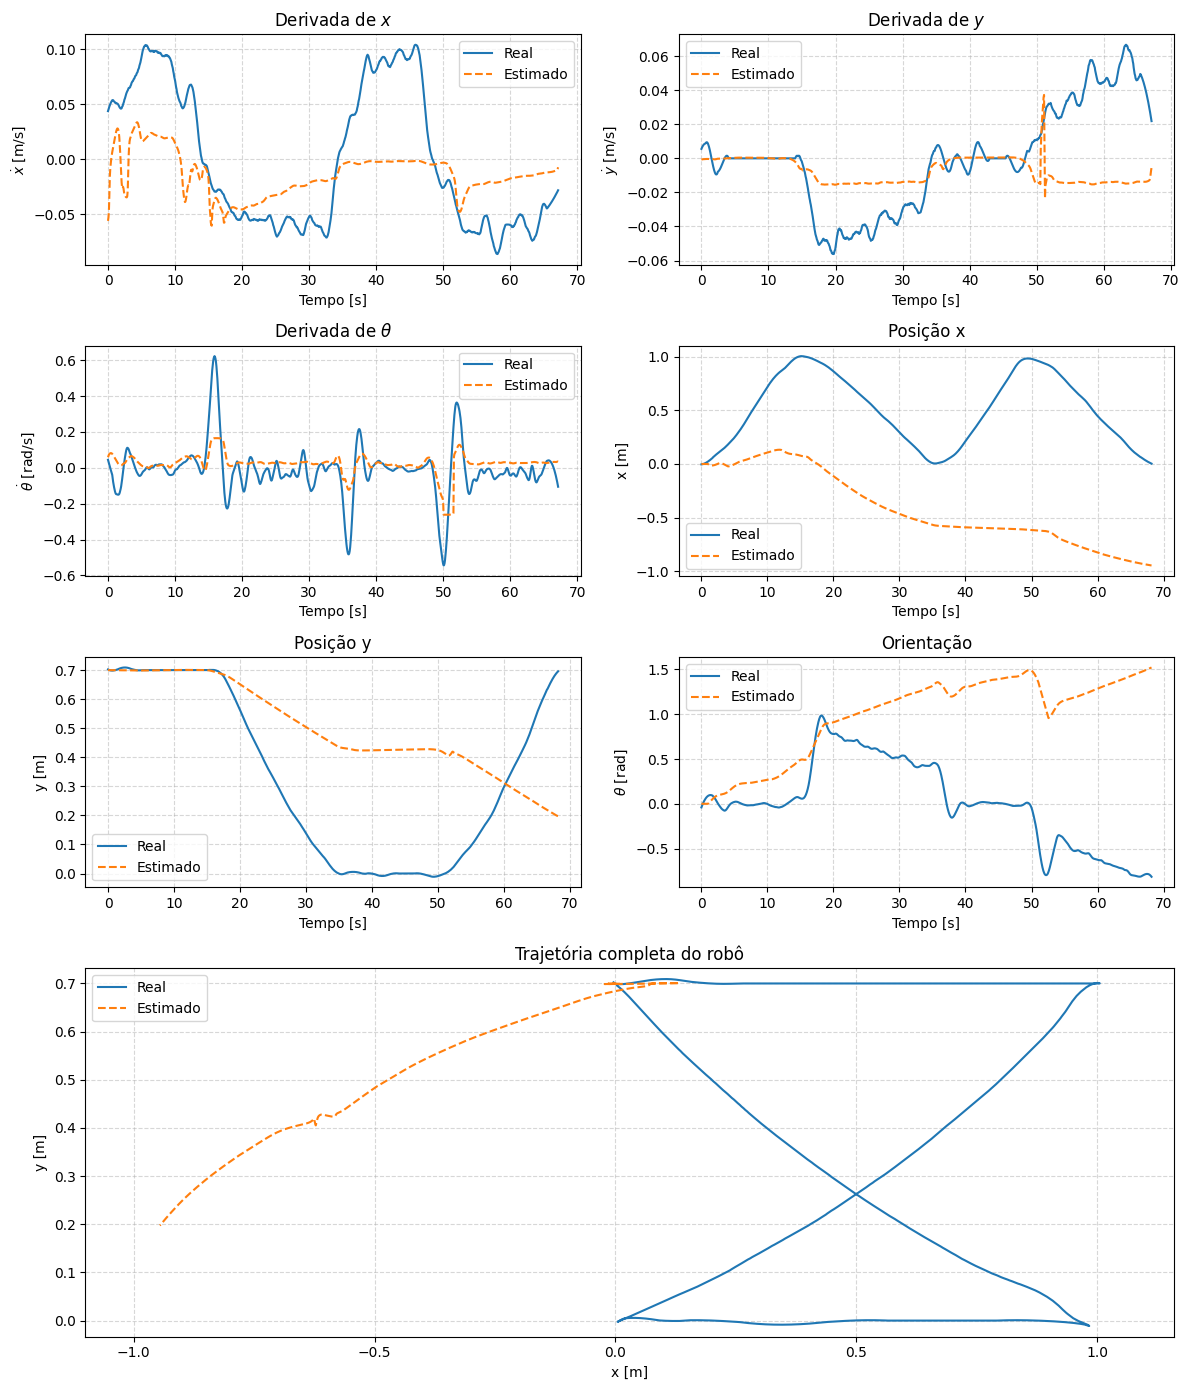

In [6]:
base_input, theta_hat, x_hat, y_hat, dtheta_hat, dx_hat, dy_hat = CompleteModelPredict(S_d,
                                                                                        S_e, x0=0.0, y0=0.7, theta0=0.0)

PlotPWM(base_input, Dataset["PwmD"], Dataset["PwmE"])

PlotTrajectory(
    x_hat, y_hat, theta_hat,
    Dataset["X"], Dataset["Y"], Dataset["Theta"],
    dx_hat, dy_hat, dtheta_hat,
    Dataset["dX"], Dataset["dY"], Dataset["dTheta"],
    )